In [ ]:
#data augmentation

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import os
# 3. Time Warp (esticando/comprimindo tempo)
from scipy.interpolate import interp1d
import ecgmentations as E

In [14]:
# Caminho do CSV de um paciente 
csv_file = "mit-bih-arrhythmia-database-1.0.0/101_labeled.csv"

# Carrega os dados
df = pd.read_csv(csv_file)

In [5]:
# Visualiza as primeiras colunas disponíveis
print(df.head())

   channel_0  channel_1  sample # type
0     -0.345      -0.16         0   NC
1     -0.345      -0.16         1   NC
2     -0.345      -0.16         2   NC
3     -0.345      -0.16         3   NC
4     -0.345      -0.16         4   NC


In [50]:
#Clean the column names: strip whitespace and surrounding quotes
df.columns = (
    df.columns
      .str.strip()                                   # remove leading/trailing spaces
      .str.replace(r"^['\"]|['\"]$", "", regex=True) # remove leading/trailing ' or "
)

In [51]:
# Verify column names (optional)
print("Columns:", df.columns.tolist())

Columns: ['channel_0', 'channel_1', 'sample #', 'type']


In [52]:
# Extract the MLII lead
signal = df['channel_0'].values

In [57]:
# Define sampling parameters
fs = 360                # sampling rate in Hz (MIT-BIH)
duration_sec = 2       # how many seconds to plot
n_samples = fs * duration_sec

In [68]:
# Cria eixo do tempo
time = np.arange(n_samples) / fs

In [69]:
# === Detecta picos ===
# Ajuste o parâmetro 'prominence' conforme necessário para pegar só os picos R
peaks, properties = find_peaks(signal[:n_samples], prominence=0.8, distance=fs*0.2)

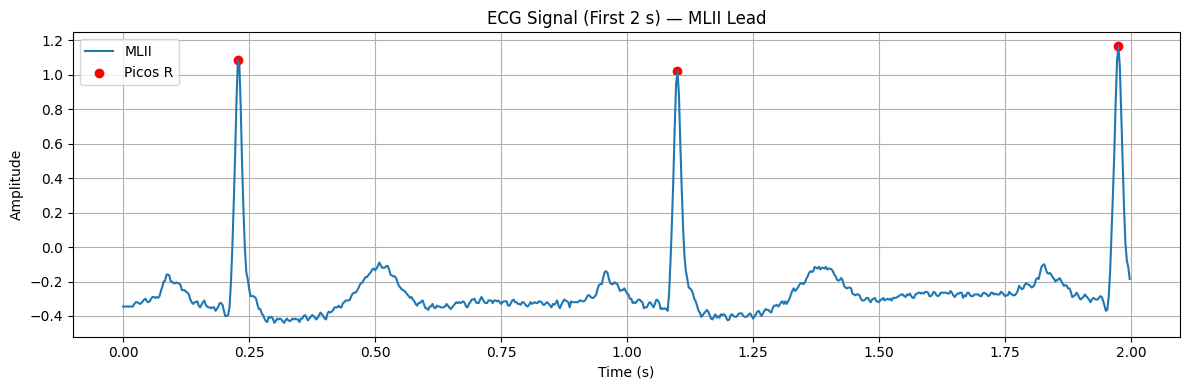

In [70]:
# 7. Plot the first 10 seconds of the MLII signal
# === Plota o sinal com picos ===
plt.figure(figsize=(12, 4))
plt.plot(time, signal[:n_samples], label="MLII")
plt.scatter(time[peaks], signal[peaks], color="red", marker="o", label="Picos R")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("ECG Signal (First 2 s) — MLII Lead")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Mostrar batimento anotado

In [6]:
def plot_beat_by_peaks(csv_path, desired_type="V", nth=0, channel="channel_0"):
    # carregar o arquivo inteiro
    df = pd.read_csv(csv_path)
    df = df.sort_values("sample #").reset_index(drop=True)

    # encontrar todas as ocorrências do rótulo desejado
    target_rows = df[df["type"] == desired_type].reset_index(drop=True)
    if len(target_rows) == 0:
        raise ValueError(f"Nenhum batimento do tipo {desired_type} encontrado.")
    
    # escolher o nth batimento (ou último se nth >= len)
    nth = min(nth, len(target_rows)-1)
    center_sample = int(target_rows.loc[nth, "sample #"])

    # extrair canal de interesse
    x = df["sample #"].values
    y = df[channel].values

    # detectar picos no sinal (ajuste height/distance conforme seu ECG)
    peaks, _ = find_peaks(y, distance=100)  

    # encontrar o pico mais próximo do sample anotado
    center_idx = np.argmin(np.abs(peaks - center_sample))
    prev_peak = peaks[center_idx - 1] if center_idx > 0 else peaks[0]
    next_peak = peaks[center_idx + 1] if center_idx < len(peaks) - 1 else peaks[-1]

    # recortar o sinal nesse intervalo
    mask = (x >= prev_peak) & (x <= next_peak)
    seg_x = x[mask]
    seg_y = y[mask]

    # plotar
    plt.figure(figsize=(10, 4))
    plt.plot(seg_x, seg_y, label=f"Sinal {channel}")
    plt.axvline(center_sample, color="red", linestyle="--", label=f"{desired_type} anotado")
    plt.axvline(prev_peak, color="gray", linestyle=":", label="pico anterior")
    plt.axvline(next_peak, color="gray", linestyle=":", label="pico próximo")

    y_center = float(df.loc[df["sample #"] == center_sample, channel].values[0])
    plt.text(center_sample, y_center + (np.ptp(seg_y)*0.1), desired_type, color="red", ha="center")

    plt.title(f"Batimento {desired_type} (sample {center_sample})")
    plt.xlabel("Sample #")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

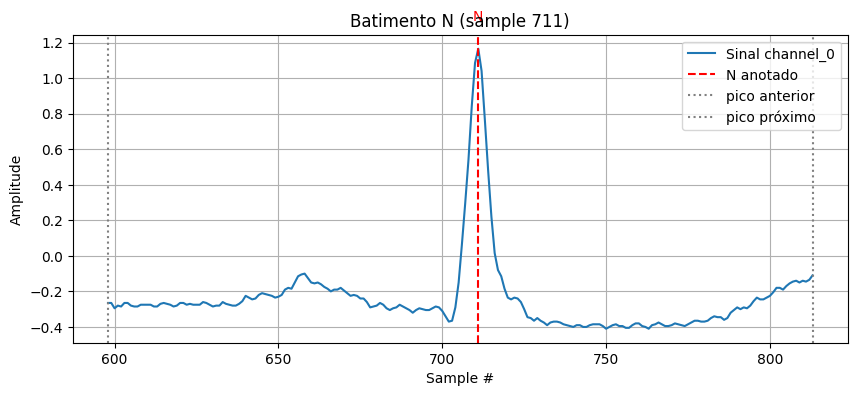

In [7]:
plot_beat_by_peaks(csv_file, desired_type="N", nth=2, channel="channel_0")

In [7]:
def plot_beat_with_margin(csv_path, desired_type="N", nth=2, channel="channel_0", margin_ratio=0.85):
    """
    Mostra um batimento delimitado pelos picos anterior e próximo,
    mas adiciona margem extra antes e depois para conferir o corte.
    
    margin_ratio: fração da largura do intervalo (ex: 0.2 = 20%)
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy.signal import find_peaks

    # carregar o arquivo
    df = pd.read_csv(csv_path)
    df = df.sort_values("sample #").reset_index(drop=True)

    # localizar batimentos do tipo desejado
    target_rows = df[df["type"] == desired_type].reset_index(drop=True)
    if len(target_rows) == 0:
        raise ValueError(f"Nenhum batimento do tipo {desired_type} encontrado.")
    
    nth = min(nth, len(target_rows)-1)
    center_sample = int(target_rows.loc[nth, "sample #"])

    # extrair canal
    x = df["sample #"].values
    y = df[channel].values

    # detectar picos
    peaks, _ = find_peaks(y, distance=100)

    # pico central
    center_idx = np.argmin(np.abs(peaks - center_sample))
    prev_peak = peaks[center_idx - 1] if center_idx > 0 else peaks[0]
    next_peak = peaks[center_idx + 1] if center_idx < len(peaks) - 1 else peaks[-1]

    # calcular margens
    interval = next_peak - prev_peak
    margin = int(interval * margin_ratio)

    start = max(0, prev_peak - margin)
    end = min(len(x)-1, next_peak + margin)

    # recorte com margem
    mask = (x >= start) & (x <= end)
    seg_x = x[mask]
    seg_y = y[mask]

    # plotagem
    plt.figure(figsize=(12, 4))
    plt.plot(seg_x, seg_y, label=f"Sinal {channel}")
    plt.axvline(center_sample, color="red", linestyle="--", label=f"{desired_type} anotado")
    plt.axvline(prev_peak, color="green", linestyle="--", label="pico anterior")
    plt.axvline(next_peak, color="blue", linestyle="--", label="pico próximo")
    plt.axvline(start, color="gray", linestyle=":", label="início com margem")
    plt.axvline(end, color="gray", linestyle=":", label="fim com margem")

    y_center = float(df.loc[df["sample #"] == center_sample, channel].values[0])
    plt.text(center_sample, y_center + (np.ptp(seg_y)*0.1), desired_type, color="red", ha="center")

    plt.title(f"Batimento {desired_type} com margem ({margin_ratio*100:.0f}%)")
    plt.xlabel("Sample #")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()


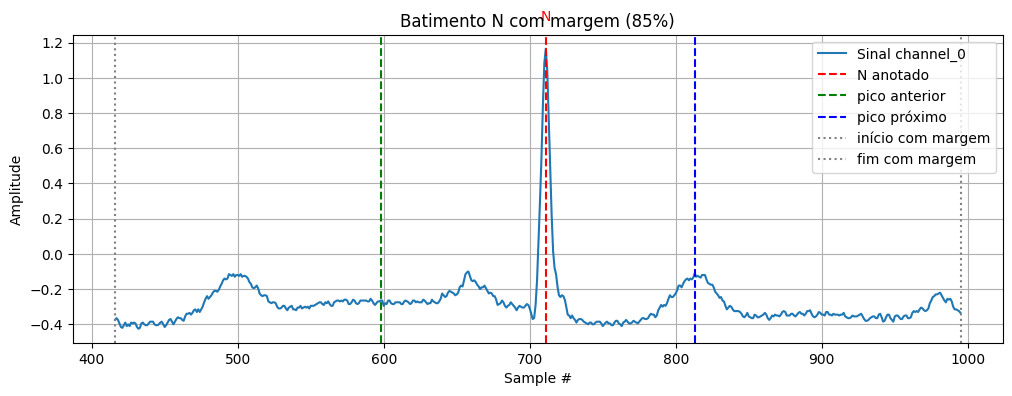

In [18]:
plot_beat_with_margin(csv_file, desired_type="N", nth=2, channel="channel_0")

In [8]:
def plot_beat_by_similar_amplitude(csv_path, desired_type="V", nth=0, channel="channel_0", amplitude_tolerance=0.15):
    """
    Isola e plota um batimento cardíaco, definindo a janela de visualização
    pelos picos R anterior e posterior que possuem amplitude similar ao pico
    do batimento anotado.

    Parâmetros:
    - csv_path (str): Caminho para o arquivo CSV.
    - desired_type (str): Rótulo do batimento a ser procurado.
    - nth (int): N-ésima ocorrência do batimento a ser plotada.
    - channel (str): Nome da coluna do canal a ser usado.
    - amplitude_tolerance (float): Tolerância para considerar amplitudes de picos
                                   como "similares". Ex: 0.15 para ±15%.
    """
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Erro: O arquivo não foi encontrado: {csv_path}")
        return
    
    df = df.sort_values("sample #").reset_index(drop=True)

    target_rows = df[df["type"] == desired_type].reset_index(drop=True)
    if not len(target_rows):
        print(f"Aviso: Nenhum batimento do tipo '{desired_type}' encontrado.")
        return
    
    nth = min(nth, len(target_rows) - 1)
    center_sample = int(target_rows.loc[nth, "sample #"])

    x = df["sample #"].values
    y = df[channel].values
    #encontra os picos
    peaks, _ = find_peaks(y, distance=100)
    if len(peaks) < 2:
        print("Aviso: Menos de dois picos R detectados no sinal.")
        return

    # 1. Encontrar o pico R associado à anotação
    center_peak_index = np.argmin(np.abs(peaks - center_sample))
    center_peak_sample = peaks[center_peak_index]
    
    # 2. Obter a amplitude desse pico central
    center_peak_amplitude = y[center_peak_sample]
    print(f"Pico central encontrado na amostra {center_peak_sample} com amplitude {center_peak_amplitude:.2f}")

    # 3. Definir a faixa de amplitude aceitável
    min_amp = center_peak_amplitude * (1 - amplitude_tolerance)
    max_amp = center_peak_amplitude * (1 + amplitude_tolerance)
    print(f"Procurando picos com amplitude entre {min_amp:.2f} e {max_amp:.2f}")

    # 4. Varrer para TRÁS procurando um pico similar
    start_peak = None
    for i in range(center_peak_index - 1, -1, -1):
        peak_amp = y[peaks[i]]
        if min_amp <= peak_amp <= max_amp:
            start_peak = peaks[i]
            break # Encontrou, pode parar de procurar
    # Se não encontrar, usa o primeiro pico do sinal como fallback
    if start_peak is None:
        start_peak = peaks[0]
        print("Aviso: Nenhum pico similar encontrado para trás. Usando o primeiro pico do sinal.")

    # 5. Varrer para FRENTE procurando um pico similar
    end_peak = None
    for i in range(center_peak_index + 1, len(peaks)):
        peak_amp = y[peaks[i]]
        if min_amp <= peak_amp <= max_amp:
            end_peak = peaks[i]
            break # Encontrou, pode parar de procurar
    # Se não encontrar, usa o último pico do sinal como fallback
    if end_peak is None:
        end_peak = peaks[-1]
        print("Aviso: Nenhum pico similar encontrado para frente. Usando o último pico do sinal.")
        
    print(f"Janela definida entre os picos nas amostras: {start_peak} e {end_peak}")

    # 6. Plotar o sinal entre os picos encontrados
    mask = (x >= start_peak) & (x <= end_peak)
    seg_x = x[mask]
    seg_y = y[mask]

    plt.figure(figsize=(12, 6))
    plt.plot(seg_x, seg_y, label=f"Sinal ({channel})")
    plt.axvline(center_sample, color="red", linestyle="--", label=f"Anotação '{desired_type}'")
    plt.axvline(start_peak, color="green", linestyle=":", label=f"Início (Pico Similar)")
    plt.axvline(end_peak, color="green", linestyle=":", label=f"Fim (Pico Similar)")
    
    # Marcar o pico central e os picos da janela
    plt.plot(center_peak_sample, y[center_peak_sample], 'ro', markersize=8)
    plt.plot([start_peak, end_peak], [y[start_peak], y[end_peak]], 'go', markersize=8)

    plt.title(f"Batimento '{desired_type}' e Picos de Amplitude Similar")
    plt.xlabel("Número da Amostra")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

Pico central encontrado na amostra 532013 com amplitude 1.53
Procurando picos com amplitude entre 1.30 e 1.76
Janela definida entre os picos nas amostras: 531776 e 532472


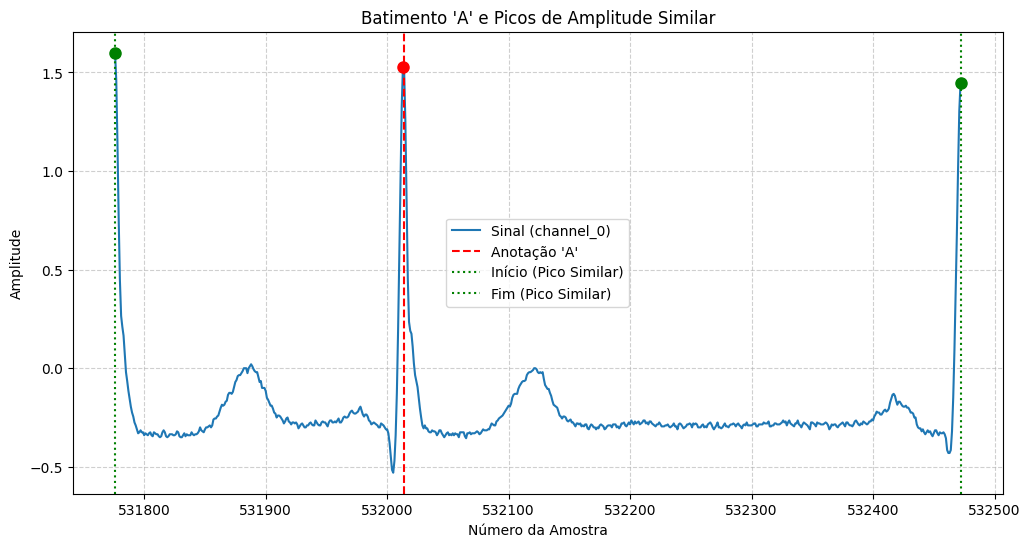

In [47]:
plot_beat_by_similar_amplitude(csv_file, desired_type="A", nth=2, channel="channel_0")

In [ ]:
#Função para retornar o DataFrame do intervalo que queremos

In [7]:
def get_beat_segment_by_similar_amplitude(csv_path, desired_type="V", nth=0, channel="channel_0", amplitude_tolerance=0.15):
    """
    Localiza um batimento e retorna os dados (amostras e amplitudes) do segmento
    delimitado por picos de amplitude similar.

    Retorna:
    - Um DataFrame do pandas com os dados do segmento.
    - None se o batimento ou um segmento válido não for encontrado.
    """
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Erro: O arquivo não foi encontrado: {csv_path}")
        return None
    
    df = df.sort_values("sample #").reset_index(drop=True)

    target_rows = df[df["type"] == desired_type].reset_index(drop=True)
    if not len(target_rows):
        print(f"Aviso: Nenhum batimento do tipo '{desired_type}' encontrado.")
        return None
    
    nth = min(nth, len(target_rows) - 1)
    center_sample = int(target_rows.loc[nth, "sample #"])

    x = df["sample #"].values
    y = df[channel].values

    peaks, _ = find_peaks(y, distance=100)
    if len(peaks) < 2:
        print("Aviso: Menos de dois picos R detectados.")
        return None

    center_peak_index = np.argmin(np.abs(peaks - center_sample))
    center_peak_sample = peaks[center_peak_index]
    center_peak_amplitude = y[center_peak_sample]

    min_amp = center_peak_amplitude * (1 - amplitude_tolerance)
    max_amp = center_peak_amplitude * (1 + amplitude_tolerance)

    start_peak = None
    for i in range(center_peak_index - 1, -1, -1):
        if min_amp <= y[peaks[i]] <= max_amp:
            start_peak = peaks[i]
            break
    if start_peak is None: start_peak = peaks[0]

    end_peak = None
    for i in range(center_peak_index + 1, len(peaks)):
        if min_amp <= y[peaks[i]] <= max_amp:
            end_peak = peaks[i]
            break
    if end_peak is None: end_peak = peaks[-1]

    # Cria a máscara e extrai o segmento do DataFrame original
    mask = (df["sample #"] >= start_peak) & (df["sample #"] <= end_peak)
    segment_df = df.loc[mask, ["sample #", channel]].copy()
    
    # Renomeia a coluna do canal para um nome genérico para facilitar o uso
    segment_df.rename(columns={channel: "amplitude"}, inplace=True)
    print(segment_df.head())
    return segment_df

In [8]:
def get_beat_segment_by_similar_amplitude_2(csv_path, desired_type="V", nth=0, channel="channel_0", amplitude_tolerance=0.15):
    """
    Localiza um batimento e retorna os dados (amostras e amplitudes) do segmento
    delimitado por picos de amplitude similar.

    Retorna:
    - Um DataFrame do pandas com os dados do segmento.
    - None se o batimento ou um segmento válido não for encontrado.
    """
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Erro: O arquivo não foi encontrado: {csv_path}")
        return None
    
    df = df.sort_values("sample #").reset_index(drop=True)

    target_rows = df[df["type"] == desired_type].reset_index(drop=True)
    if not len(target_rows):
        print(f"Aviso: Nenhum batimento do tipo '{desired_type}' encontrado.")
        return None
    
    nth = min(nth, len(target_rows) - 1)
    center_sample = int(target_rows.loc[nth, "sample #"])

    x = df["sample #"].values
    y = df[channel].values

    peaks, _ = find_peaks(y, distance=100)
    if len(peaks) < 2:
        print("Aviso: Menos de dois picos R detectados.")
        return None

    center_peak_index = np.argmin(np.abs(peaks - center_sample))
    center_peak_sample = peaks[center_peak_index]
    center_peak_amplitude = y[center_peak_sample]

    min_amp = center_peak_amplitude * (1 - amplitude_tolerance)
    max_amp = center_peak_amplitude * (1 + amplitude_tolerance)

    # Localiza picos anteriores e posteriores com amplitude semelhante
    start_peak = None
    for i in range(center_peak_index - 1, -1, -1):
        if min_amp <= y[peaks[i]] <= max_amp:
            start_peak = peaks[i]
            break
    if start_peak is None:
        start_peak = peaks[0]

    end_peak = None
    for i in range(center_peak_index + 1, len(peaks)):
        if min_amp <= y[peaks[i]] <= max_amp:
            end_peak = peaks[i]
            break
    if end_peak is None:
        end_peak = peaks[-1]

    # Cria a máscara e extrai o segmento completo (mantendo todas as colunas originais)
    mask = (df["sample #"] >= start_peak) & (df["sample #"] <= end_peak)
    segment_df = df.loc[mask].copy()  # <— agora mantém TODAS as colunas

    # Opcional: renomeia a coluna do canal atual para "amplitude"
    # (mantendo as demais colunas intactas)
    if channel in segment_df.columns:
        segment_df.rename(columns={channel: "amplitude"}, inplace=True)
    
    print(segment_df.head())
    return segment_df


In [10]:
def plot_beat_segment(segment_df, title="Segmento de Batimento Cardíaco"):
    """
    Função auxiliar para plotar um segmento de batimento de um DataFrame.
    """
    if segment_df is None or segment_df.empty:
        print("DataFrame vazio. Nada para plotar.")
        return

    plt.figure(figsize=(12, 6))
    plt.plot(segment_df["sample #"], segment_df["amplitude"], label="Sinal")
    plt.title(title)
    plt.xlabel("Número da Amostra")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

        sample #  amplitude
531776    531776      1.600
531777    531777      1.460
531778    531778      1.135
531779    531779      0.755
531780    531780      0.445


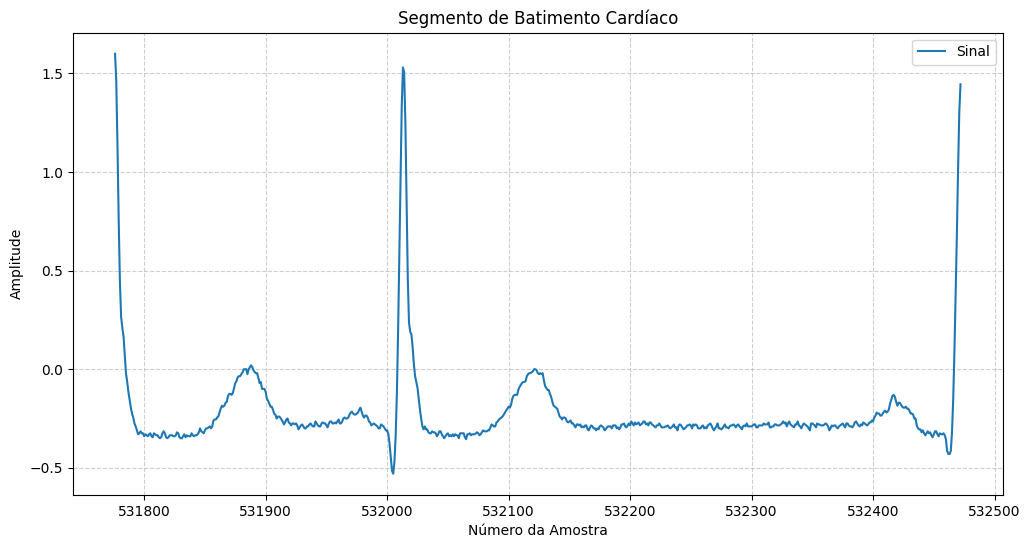

In [61]:
plot_beat_segment(get_beat_segment_by_similar_amplitude(csv_file, desired_type="A", nth=2, channel="channel_0"), title="Segmento de Batimento Cardíaco")

In [ ]:
#Salvar o data augmentation

In [24]:
def save_augmented(segment_df, save_path, aug_name):
    """Salva segmento em CSV no formato padrão."""
    augmented_df = segment_df.copy()
    augmented_df["channel_0"] = augmented_df["amplitude"]
    augmented_df = augmented_df[["channel_0", "sample #", "type"]]
    # adiciona coluna type como "AUG"
    #augmented_df["type"] = aug_name
    augmented_df.to_csv(save_path, index=False)

In [25]:
#Diferentes tipos de data augmentation

In [29]:
# 1. Jitter (ruído gaussiano)
def augment_jitter(segment_df, sigma=0.01, save_path="aug_jitter.csv"):
    augmented_df = segment_df.copy()
    noise = np.random.normal(0, sigma, size=len(segment_df))
    augmented_df["amplitude"] += noise
    save_augmented(augmented_df, save_path, "jitter")
    print(augmented_df.head())
    return augmented_df

        amplitude  channel_1  sample # type
531776      1.600     -0.095    531776   NC
531777      1.460     -0.110    531777    N
531778      1.135     -0.110    531778   NC
531779      0.755     -0.105    531779   NC
531780      0.445     -0.085    531780   NC
        amplitude  channel_1  sample # type
531776   1.588941     -0.095    531776   NC
531777   1.476468     -0.110    531777    N
531778   1.142456     -0.110    531778   NC
531779   0.750543     -0.105    531779   NC
531780   0.439276     -0.085    531780   NC


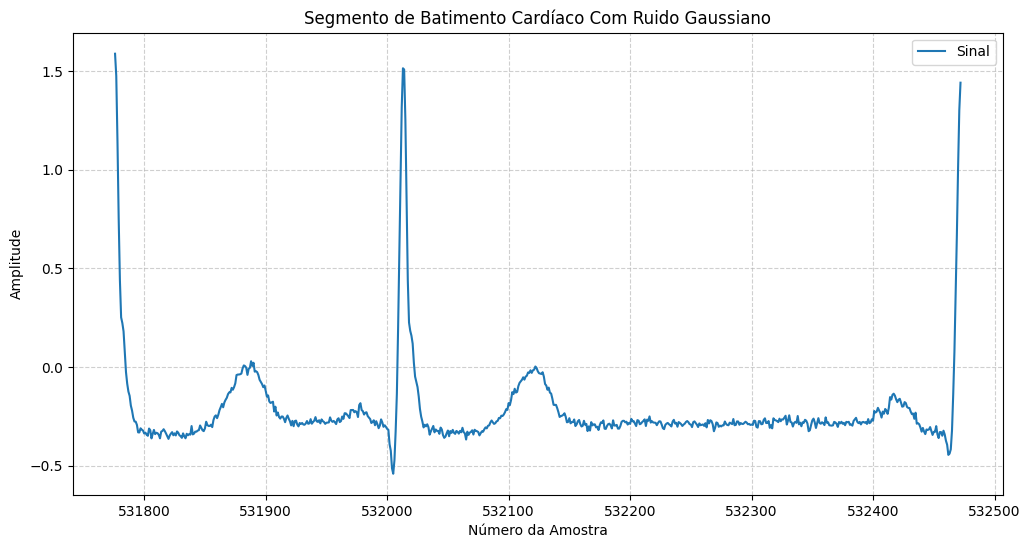

In [30]:
plot_beat_segment(augment_jitter(get_beat_segment_by_similar_amplitude_2(csv_file, desired_type="A", nth=2, channel="channel_0")), title="Segmento de Batimento Cardíaco Com Ruido Gaussiano")

In [13]:
# 2. Scaling (variação de ganho)
def augment_scaling(segment_df, factor_range=(0.9, 1.1), save_path="aug_scaling.csv"):
    factor = np.random.uniform(*factor_range)
    augmented_df = segment_df.copy()
    augmented_df["amplitude"] *= factor
    save_augmented(augmented_df, save_path, f"scaling_{factor:.2f}")
    return augmented_df

        sample #  amplitude
531776    531776      1.600
531777    531777      1.460
531778    531778      1.135
531779    531779      0.755
531780    531780      0.445


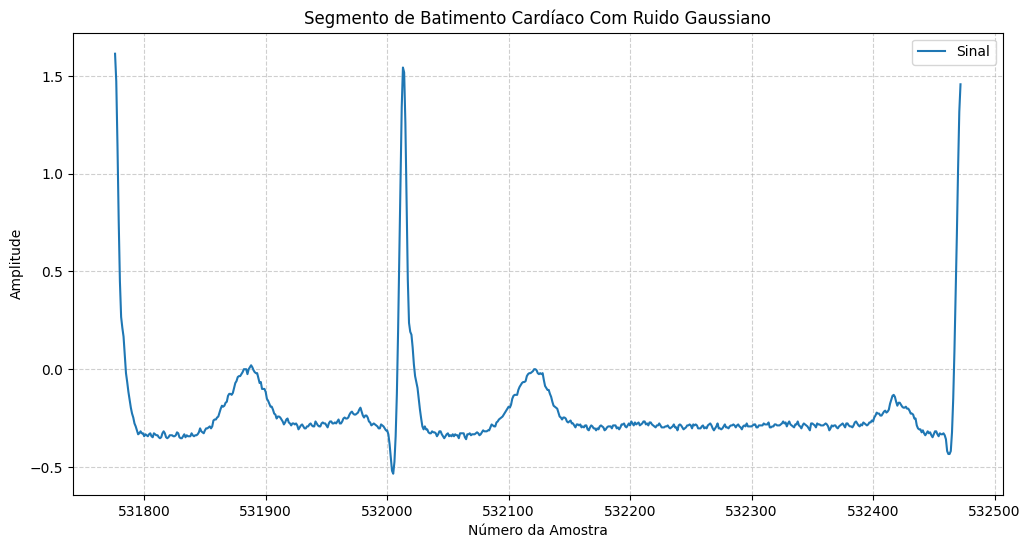

In [12]:
plot_beat_segment(augment_scaling(get_beat_segment_by_similar_amplitude(csv_file, desired_type="A", nth=2, channel="channel_0")), title="Segmento de Batimento Cardíaco Com Variação do ganho")

In [14]:
def augment_time_warp(segment_df, warp_factor_range=(0.5, 1.5), save_path="aug_timewarp.csv"):
    warp_factor = np.random.uniform(*warp_factor_range)
    x = segment_df["sample #"].values
    y = segment_df["amplitude"].values
    
    new_len = int(len(x) * warp_factor)
    new_x = np.linspace(x.min(), x.max(), new_len)
    
    f = interp1d(x, y, kind="linear")
    new_y = f(new_x)
    
    augmented_df = pd.DataFrame({"sample #": new_x.astype(int), "amplitude": new_y})
    save_augmented(augmented_df, save_path, f"timewarp_{warp_factor:.2f}")
    return augmented_df

        sample #  amplitude
531776    531776      1.600
531777    531777      1.460
531778    531778      1.135
531779    531779      0.755
531780    531780      0.445


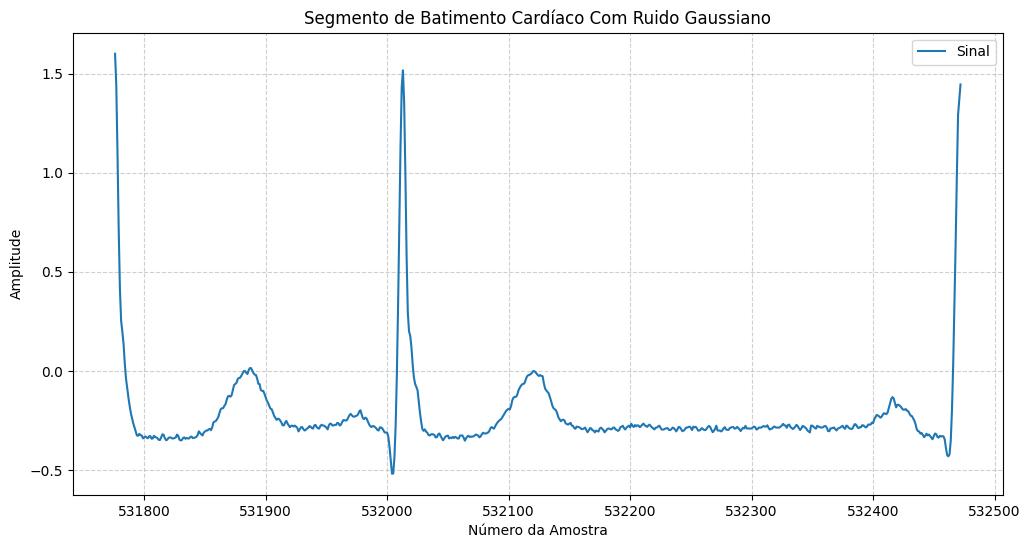

In [28]:
plot_beat_segment(augment_time_warp(get_beat_segment_by_similar_amplitude(csv_file, desired_type="A", nth=2, channel="channel_0")), title="Segmento de Batimento Cardíaco Com Ruido Gaussiano")

In [15]:
def comparar_sinais(original_df, augmented_df, title="Comparação de Sinais"):
    """
    Plota o sinal original e um sinal aumentado no mesmo gráfico para comparação.
    """
    plt.figure(figsize=(12, 6))
    
    # Plota o sinal original
    plt.plot(original_df["sample #"], original_df["amplitude"], 
             label="Sinal Original", color="blue", linewidth=2, alpha=0.9)
    
    # Plota o sinal aumentado
    plt.plot(augmented_df["sample #"], augmented_df["amplitude"], 
             label="Sinal Aumentado (Time Warp)", color="red", linestyle="--", linewidth=2)
    
    plt.title(title)
    plt.xlabel("Número da Amostra")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

        sample #  amplitude
531776    531776      1.600
531777    531777      1.460
531778    531778      1.135
531779    531779      0.755
531780    531780      0.445
--- Realizando teste de COMPRESSÃO (fator 0.6) ---


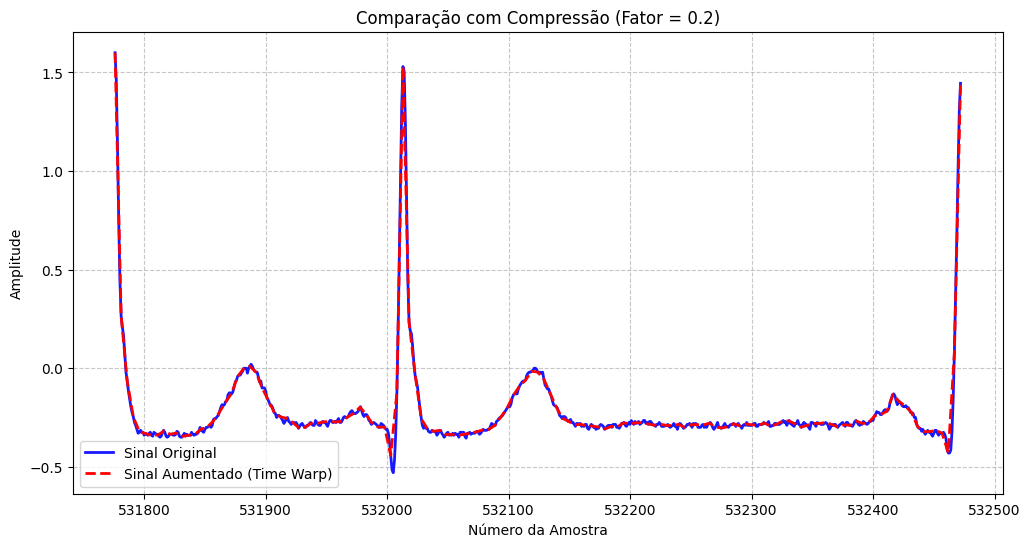


--- Realizando teste de ESTICAMENTO (fator 1.5) ---


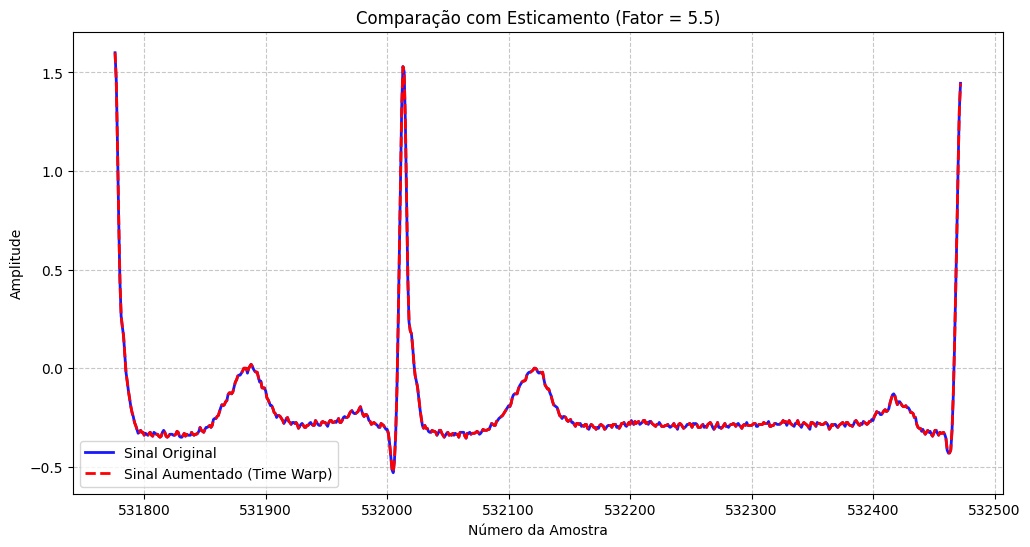

In [16]:
from scipy.interpolate import interp1d
import pandas as pd
import numpy as np

caminho_do_arquivo_csv = "mit-bih-arrhythmia-database-1.0.0/101_labeled.csv"

# Passo 1: Obtenha um segmento original para trabalhar
segmento_original_df = get_beat_segment_by_similar_amplitude(
    csv_path=caminho_do_arquivo_csv,
    desired_type="A", # Ou qualquer tipo que você queira testar
    nth=2
)

if segmento_original_df is not None:
    # --- TESTE 1: COMPRESSÃO FORÇADA ---
    print("--- Realizando teste de COMPRESSÃO (fator 0.6) ---")
    warp_factor_comprimir = 0.2
    
    x = segmento_original_df["sample #"].values
    y = segmento_original_df["amplitude"].values
    
    new_len = int(len(x) * warp_factor_comprimir)
    new_x = np.linspace(x.min(), x.max(), new_len)
    
    f = interp1d(x, y, kind="linear")
    new_y = f(new_x)
    
    segmento_comprimido_df = pd.DataFrame({"sample #": new_x, "amplitude": new_y})
    
    # Compare o original com o comprimido
    comparar_sinais(segmento_original_df, segmento_comprimido_df, 
                    title=f"Comparação com Compressão (Fator = {warp_factor_comprimir})")

    # --- TESTE 2: ESTICAMENTO FORÇADO ---
    print("\n--- Realizando teste de ESTICAMENTO (fator 1.5) ---")
    warp_factor_esticar = 5.5
    
    new_len = int(len(x) * warp_factor_esticar)
    new_x = np.linspace(x.min(), x.max(), new_len)
    
    new_y = f(new_x) # Reutilizando a mesma função de interpolação f
    
    segmento_esticado_df = pd.DataFrame({"sample #": new_x, "amplitude": new_y})
    
    # Compare o original com o esticado
    comparar_sinais(segmento_original_df, segmento_esticado_df, 
                    title=f"Comparação com Esticamento (Fator = {warp_factor_esticar})")

In [17]:
# 4. Random Dropout (zera trechos aleatórios)
def augment_dropout(segment_df, drop_prob=0.05, save_path="aug_dropout.csv"):
    augmented_df = segment_df.copy()
    mask = np.random.rand(len(augmented_df)) < drop_prob
    augmented_df.loc[mask, "amplitude"] = 0.0
    save_augmented(augmented_df, save_path, f"dropout_p{drop_prob}")
    return augmented_df

        sample #  amplitude
531776    531776      1.600
531777    531777      1.460
531778    531778      1.135
531779    531779      0.755
531780    531780      0.445


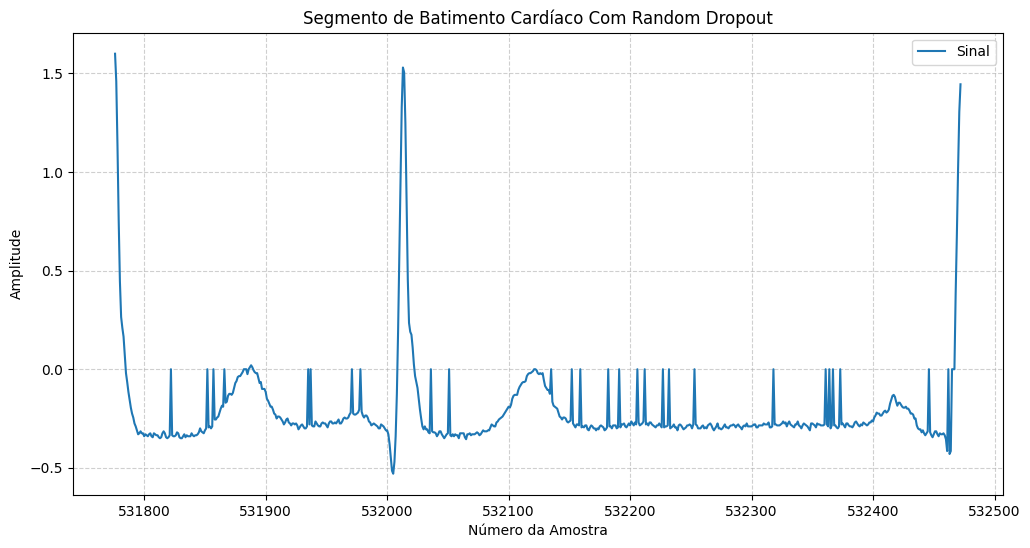

In [47]:
plot_beat_segment(augment_dropout(get_beat_segment_by_similar_amplitude(csv_file, desired_type="A", nth=2, channel="channel_0")), title="Segmento de Batimento Cardíaco Com Random Dropout")

In [18]:
# 5. Magnitude Warp (deforma amplitude no tempo)
def augment_magnitude_warp(segment_df, sigma=0.2, knot=4, save_path="aug_magwarp.csv"):
    from scipy.interpolate import CubicSpline
    x = np.arange(len(segment_df))
    y = segment_df["amplitude"].values

    # pontos de controle
    random_warps = np.random.normal(loc=1.0, scale=sigma, size=knot+2)
    warp_steps = np.linspace(0, len(segment_df)-1, num=knot+2)
    warp = CubicSpline(warp_steps, random_warps)(x)

    augmented_df = segment_df.copy()
    augmented_df["amplitude"] = y * warp
    save_augmented(augmented_df, save_path, "magwarp")
    return augmented_df

        sample #  amplitude
531776    531776      1.600
531777    531777      1.460
531778    531778      1.135
531779    531779      0.755
531780    531780      0.445


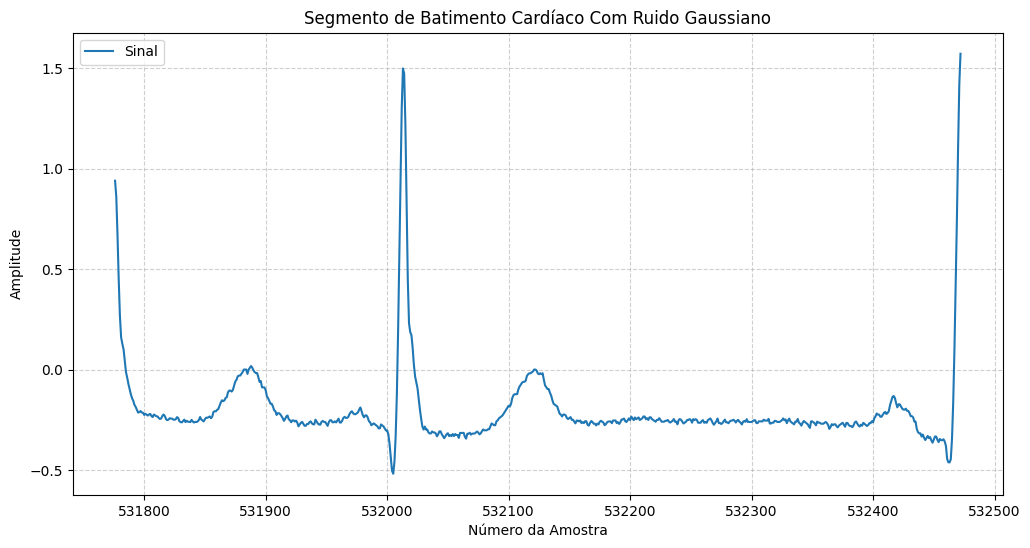

In [36]:
plot_beat_segment(augment_magnitude_warp(get_beat_segment_by_similar_amplitude(csv_file, desired_type="A", nth=2, channel="channel_0")), title="Segmento de Batimento Cardíaco Com Magnitude Warp")

In [41]:
def augment_time_reverse(segment_df, save_path="aug_timereverse.csv"):
    """
    Inverte o segmento de ECG no eixo do tempo.

    A primeira amostra se torna a última, a segunda se torna a penúltima, e assim por diante.

    Parâmetros:
    - segment_df (pd.DataFrame): DataFrame contendo as colunas 'sample #' e 'amplitude'.
    - save_path (str): Caminho opcional para salvar o DataFrame aumentado.

    Retorna:
    - pd.DataFrame: O DataFrame com a série de amplitudes invertida.
    """
    # É uma boa prática criar uma cópia para não modificar o DataFrame original
    augmented_df = segment_df.copy()
    
    # Pega os valores de amplitude como um array numpy
    y = segment_df["amplitude"].values
    
    # A "mágica" acontece aqui: inverte a ordem de todos os elementos do array
    reversed_y = y[::-1]
    
    # Atribui o array invertido de volta à coluna 'amplitude' do novo DataFrame
    augmented_df["amplitude"] = reversed_y
    
    # Salva o resultado (se a função save_augmented estiver disponível)
    # save_augmented(augmented_df, save_path, "timereverse")
    
    return augmented_df

        sample #  amplitude
531776    531776      1.600
531777    531777      1.460
531778    531778      1.135
531779    531779      0.755
531780    531780      0.445


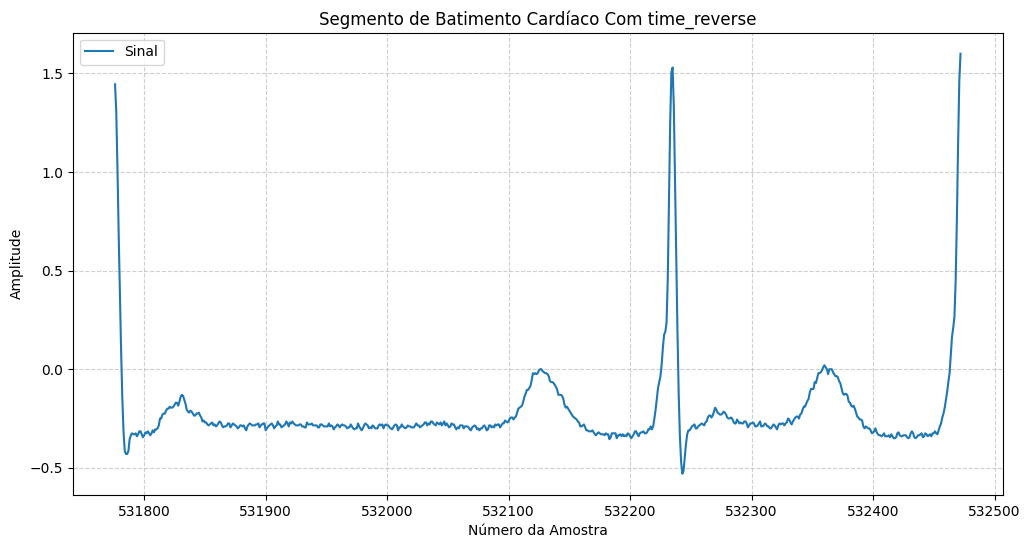

In [45]:
plot_beat_segment(augment_time_reverse(get_beat_segment_by_similar_amplitude(csv_file, desired_type="A", nth=2, channel="channel_0")), title="Segmento de Batimento Cardíaco Com time_reverse")

In [43]:
def augment_add_sine_pulse(segment_df, amplitude=0.1, frequency=1.0, random_phase=True, save_path="aug_sinepulse.csv"):
    """
    Adiciona uma onda senoidal ao sinal de ECG para simular deriva da linha de base.

    Parâmetros:
    - segment_df (pd.DataFrame): DataFrame com as colunas 'sample #' e 'amplitude'.
    - amplitude (float): A amplitude (altura) máxima da onda senoidal a ser adicionada.
    - frequency (float): O número de ciclos completos da onda senoidal ao longo do segmento.
    - random_phase (bool): Se True, a onda senoidal começará em um ponto aleatório do seu ciclo.
    - save_path (str): Caminho opcional para salvar o DataFrame aumentado.

    Retorna:
    - pd.DataFrame: O DataFrame com a onda senoidal adicionada.
    """
    augmented_df = segment_df.copy()
    
    y = segment_df["amplitude"].values
    
    # Cria um eixo de tempo de 0 ao comprimento do sinal
    x = np.arange(len(y))
    
    # Define a fase inicial da onda (pode ser aleatória ou zero)
    phase = np.random.uniform(0, 2 * np.pi) if random_phase else 0
    
    # Gera a onda senoidal
    # A fórmula garante que o número de 'frequency' ciclos completos se encaixe no comprimento do sinal
    sine_wave = amplitude * np.sin(2 * np.pi * frequency * (x / len(x)) + phase)
    
    # Adiciona a onda senoidal ao sinal original
    augmented_df["amplitude"] = y + sine_wave
    
    # Salva o resultado (opcional)
    # save_augmented(augmented_df, save_path, f"sine_amp{amplitude}_freq{frequency}")
    
    return augmented_df

In [ ]:
plot_beat_segment(augment_add_sine_pulse(get_beat_segment_by_similar_amplitude(csv_file, desired_type="A", nth=2, channel="channel_0")), title="Segmento de Batimento Cardíaco Com sine_pulse")

In [3]:
def rename_augmented_data(csv_address, notation):
# Exemplo: caso você tenha o DataFrame já carregado como df
# (ou pode carregar de um CSV, Excel etc.)

    df = pd.read_csv(csv_address)
    
    # Encontrar o índice (linha) do maior valor da coluna 'channel_0'
    idx_max = df['channel_0'].idxmax()
    
    # Modificar todas as linhas da coluna 'type' para 'NC'
    df['type'] = 'NC'
    
    # Modificar a linha do maior valor para o novo valor desejado
    df.loc[idx_max, 'type'] = notation  # troque 'dado' pelo valor que você quiser
    
    # Ver resultado
    print(df)
